In [27]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Data, Models, and Utilities
from sklearn.datasets import fetch_california_housing # Using California Housing (Boston is deprecated)
from sklearn.tree import DecisionTreeClassifier # Changed from DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree

# Set a style for plots
sns.set_style("whitegrid")

---------------
Load the "drivers_final2_df.csv" dataset as crash_df.

In [5]:
crash_df = pd.read_csv(
    "https://raw.githubusercontent.com/Alissa-Ouspen/data201_alissa/main/final/drivers_final3_df.csv",
    dtype={'medication_use': str}
)

# To avoid slowing processing speed, specify data type for
# column 35 (medication_use) as str

In [6]:
# DtypeWarning: Columns (35) have mixed types.
# Specify dtype option on import or set low_memory=False.

# Identify label for column 35
print(f"The label for column 35 is: {crash_df.columns[35]}")



The label for column 35 is: medication_use


In [7]:
columns_to_analyze = ['Vehicle_Num', 'Collision_Type', 'Weather',
       'Surface_Condition', 'Ambient_Light', 'Driver_At_Fault',
       'Injury_Severity', 'Drivers_License_State',
       'Vehicle_Damage', 'Speed_Limit',
        'Junction', 'Intersection_Type',
        'Road_Condition', 'Crash_Hour', 'Crash_Month',
       'Vehicle_Age', 'alc_drug_med', 'Driver_Distract_YN']

crash_analysis_df = crash_df[columns_to_analyze].copy()

crash_analysis_df.head()

,Vehicle_Num,Collision_Type,Weather,Surface_Condition,Ambient_Light,Driver_At_Fault,Injury_Severity,Drivers_License_State,Vehicle_Damage,Speed_Limit,Junction,Intersection_Type,Road_Condition,Crash_Hour,Crash_Month,Vehicle_Age,alc_drug_med,Driver_Distract_YN
0,0,HEAD ON COLLISIONS,Clear,Dry,Dark - Lighted,No,Suspected Minor Injury,MD,Disabling,40,NaN,NaN,No Defects,22,5,8.0,No,No
1,1,HEAD ON COLLISIONS,Clear,Dry,Dark - Lighted,Yes,No Apparent Injury,MD,Disabling,40,NaN,NaN,No Defects,22,5,0.0,Yes,NaN
2,2,REAR END COLLISIONS,Clear,Dry,Dark - Lighted,No,No Apparent Injury,MD,Disabling,35,ACCELERATION/DECELERATION LANE,NaN,No Defects,21,5,3.0,No,No
3,3,REAR END COLLISIONS,Clear,Dry,Dark - Lighted,No,No Apparent Injury,NaN,Disabling,35,ACCELERATION/DECELERATION LANE,NaN,No Defects,21,5,21.0,Yes,NaN
4,4,ANGLE COLLISIONS,Clear,Dry,Dark - Lighted,Yes,No Apparent Injury,MD,Functional,25,CROSSOVER RELATED,NaN,No Defects,21,5,1.0,No,NaN
5,5,ANGLE COLLISIONS,Clear,Dry,Dark - Lighted,No,No Apparent Injury,MD,Disabling,45,CROSSOVER RELATED,NaN,No Defects,21,5,6.0,No,No
6,6,OTHER / SINGLE VEHICLE,Clear,Dry,Dark,No,NaN,NaN,Vehicle Not at Scene,25,NaN,NaN,NaN,20,5,NaN,NaN,NaN
7,7,ANGLE COLLISIONS,Clear,Dry,Daylight,No,Possible Injury,MD,Disabling,40,INTERSECTION RELATED,PERPENDICULAR,No Defects,19,5,6.0,No,No
8,8,ANGLE COLLISIONS,Clear,Dry,Daylight,Yes,No Apparent Injury,MD,Disabling,30,INTERSECTION RELATED,PERPENDICULAR,No Defects,19,5,17.0,No,No
9,9,OTHER / SINGLE VEHICLE,Clear,Dry,Daylight,Yes,No Apparent Injury,MD,Disabling,35,NaN,NaN,No Defects,16,5,15.0,No,NaN


Fields_to_analyze_table
--------------------------------------------------------------------
--------------------------------------------------------------------
| Field                      | count  | dtype          | to_analyze |
|:---------------------------|:-------|:---------------|:-----------|
| Vehicle_Num                | 214273 | index int         |  yes       |
| Collision_Type             | 6      | cat        |     consider       |
| Weather                    | 9      | cat        |     consider       |
| Surface_Condition          | 11     | cat         |    consider       |
| Ambient_Light              | 5      | cat         |      consider      |
| Driver_At_Fault            | 2      | cat   DV?    |      yes      |
| Injury_Severity            | 5      | cat   DV?     |     yes       |
| Drivers_License_State      | 55     | cat        |    no        |
| Vehicle_Damage             | 6      | cat  DV?      |     yes       |
| Speed_Limit                | 16     | numeric int         |   yes         |
| Junction                   | 10     | cat       |       consider     |
| Intersection_Type          | 7      | cat        |        consider    |
| Road_Condition             | 8      | cat        |       consider     |
| Crash_Hour                 | 24     | numeric int  IV       |    yes        |
| Crash_Month                | 12     | numeric int  IV      |      yes      |
| alc_drug_med             | 3      | cat         |        yes    |
| Vehicle_Age                | 67     | numeric int  IV        |     yes       |
| Driver_Distract_YN         | 3     | cat       |     yes       |


-------------
####Prepare data for Train/Test split by encoding data
(Yes to 1, No to 0)
Since the dataset is so large, we can afford to drop rows where data for  
any of the three variables are missing (NaN).  

#####**Idea for future research question:**  
does dropping the NaN data from the training set provide better or worse prediction  
outcomes as compared to substituting the mode of that column for the NaN?

In [11]:
# Identify the columns to consider for dropping NaNs
relevant_cols = ['alc_drug_med', 'Driver_Distract_YN', 'Driver_At_Fault']

# Drop rows where any of the relevant columns have NaN values
# Use .copy() to ensure use of separate DataFrame, avoid SettingWithCopyWarning
cleaned_crash_df = crash_df.dropna(subset=relevant_cols).copy()

X = cleaned_crash_df[['alc_drug_med', 'Driver_Distract_YN']].copy()
y = cleaned_crash_df['Driver_At_Fault'].copy()

# Encode categorical features in X
le_X = LabelEncoder()
for col in X.columns:
    X[col] = le_X.fit_transform(X[col])

# Encode categorical target variable y
le_y = LabelEncoder()
y = le_y.fit_transform(y)

### LabelEncoder Mappings
for features and target variable.  
Check that labels are applied correctly.

In [12]:
# Display the mapping for 'alc_drug_med' and 'Driver_Distract_YN'

print("Mapping for Features (X):")
# Since le_X was fit on each column iteratively,
# must re-fit a temporary encoder to show the classes for each specific column
# if they had different sets of unique values.

temp_le = LabelEncoder()
for col_name in ['alc_drug_med', 'Driver_Distract_YN']:
    unique_values = crash_df[col_name].dropna().unique()
    temp_le.fit(unique_values)
    print(f"  {col_name}: {list(zip(temp_le.classes_, range(len(temp_le.classes_))))}")

print("\nMapping for Target Variable (y - Driver_At_Fault):")
# The le_y encoder was fit directly on the 'Driver_At_Fault' column.
print(f"  Driver_At_Fault: {list(zip(le_y.classes_, range(len(le_y.classes_))))}")

Mapping for Features (X):
  alc_drug_med: [('No', 0), ('Yes', 1)]
  Driver_Distract_YN: [('No', 0), ('Yes', 1)]

Mapping for Target Variable (y - Driver_At_Fault):
  Driver_At_Fault: [('No', 0), ('Yes', 1)]


-----------
####Train/Test split
Set up design matrix and response vector.   
Create a train/test split.  
No need to scale or standardize data for these methods.

In [13]:


# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dataset features: {list(X.columns)}")
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Dataset features: ['alc_drug_med', 'Driver_Distract_YN']

Training set size: 26098 samples
Testing set size: 6525 samples


------------
####Decision Tree Regressor
Initialize and train the regressor,  
then make predictions.

In [16]:
# Initialize and train the Decision Tree Classifier

# Usually, set max_depth to control complexity and prevent extreme overfitting
# With only two feature variables, this is irrelevant
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42) # Changed to Classifier
dt_model.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_test)

####Model Metrics for Decision Tree:  
calculate the Mean Squared Error (MSE), R^2, and the accuracy score.



In [28]:
# Calculate metrics
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("--- Decision Tree Regressor Metrics ---")
print(f"Mean Squared Error (MSE): {dt_mse:.3f}")
print(f"R-squared (R2) Score: {dt_r2:.3f}")
print(f"Accuracy Score: {dt_accuracy:.3f}")

# Store results for comparison
dt_results = {'MSE': dt_mse, 'R2': dt_r2, 'Accuracy': dt_accuracy,  'Model': 'Decision Tree'}

--- Decision Tree Regressor Metrics ---
Mean Squared Error (MSE): 0.220
R-squared (R2) Score: 0.040
Accuracy Score: 0.780


----------------
####Visualizing the Decision Tree
using sklearn.tree.plot_tree

--- Decision Tree Structure Visualization ---


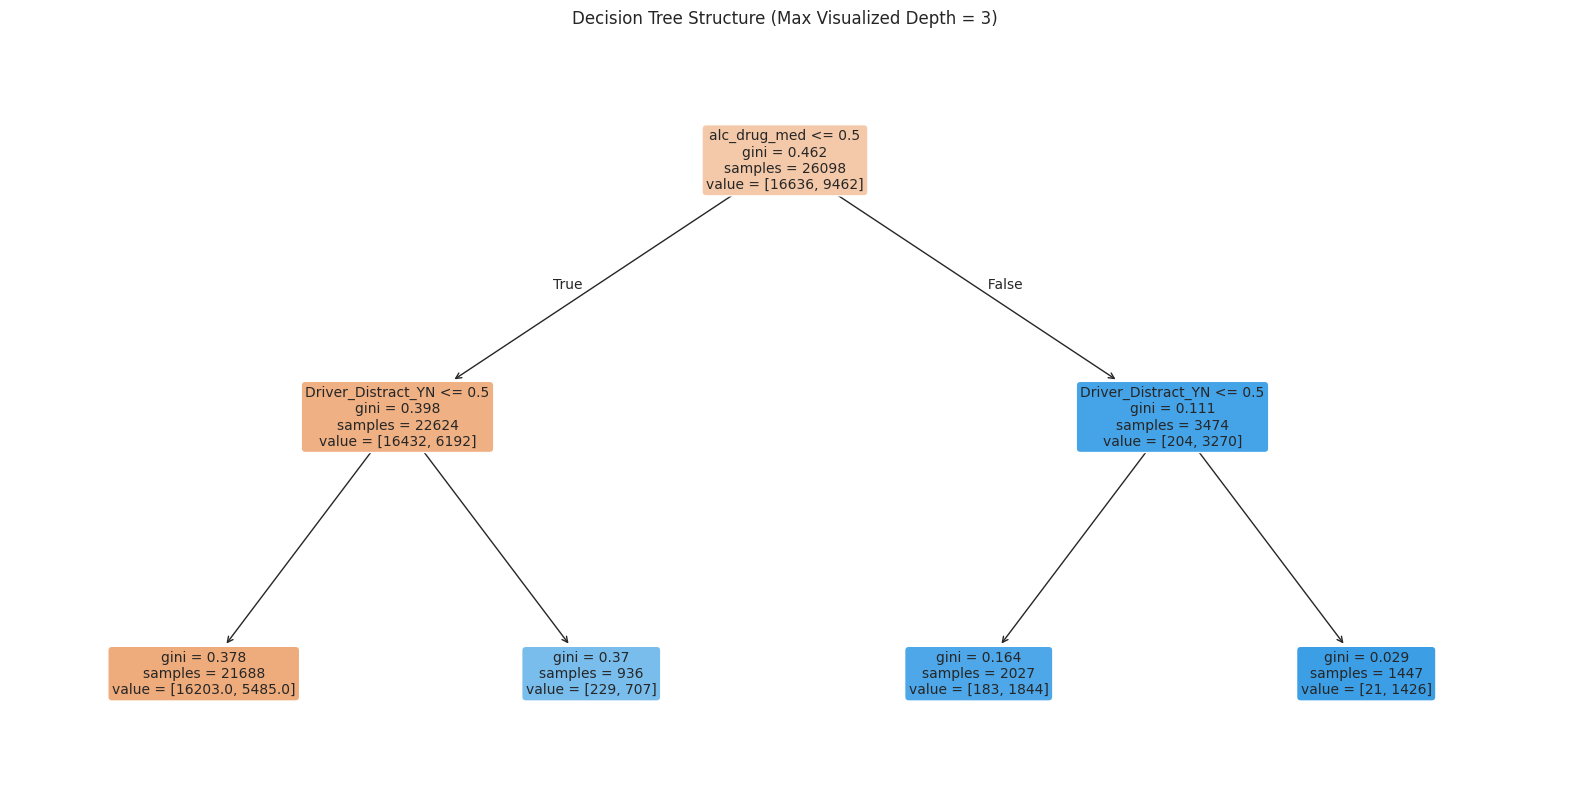

In [19]:
print("--- Decision Tree Structure Visualization ---")

# Set the maximum depth to visualize for readability
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    max_depth=3,  # Limit depth for a clearer image
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Decision Tree Structure (Max Visualized Depth = 3)")
plt.show()

## New Analysis: Mode Imputation for Missing Values

This section re-runs the analysis, but instead of dropping rows with NaN values in the key columns, it imputes them with the mode of their respective columns.

In [21]:
# Identify the columns to consider for imputation
relevant_cols_mode = ['alc_drug_med', 'Driver_Distract_YN', 'Driver_At_Fault']

# Create a copy of the original crash_df to ensure previous analysis is untouched
processed_crash_df_mode = crash_df.copy()

# Impute NaN values in relevant_cols_mode with the mode of each column
for col in relevant_cols_mode:
    mode_val = processed_crash_df_mode[col].mode()[0] # Get the first mode if multiple exist
    processed_crash_df_mode[col] = processed_crash_df_mode[col].fillna(mode_val)

# Define features (X_mode) and target (y_mode) from the mode-imputed DataFrame
X_mode = processed_crash_df_mode[['alc_drug_med', 'Driver_Distract_YN']].copy()
y_mode = processed_crash_df_mode['Driver_At_Fault'].copy()

# Encode categorical features in X_mode
le_X_mode = LabelEncoder()
for col in X_mode.columns:
    X_mode[col] = le_X_mode.fit_transform(X_mode[col])

# Encode categorical target variable y_mode
le_y_mode = LabelEncoder()
y_mode = le_y_mode.fit_transform(y_mode)

print("Data preparation with mode imputation complete.")

Data preparation with mode imputation complete.


### LabelEncoder Mappings (with Mode Imputation)

Let's verify the mappings after mode imputation, as `LabelEncoder` was re-fit.

In [22]:
print("Mapping for Features (X_mode):")
temp_le_mode = LabelEncoder()
for col_name in ['alc_drug_med', 'Driver_Distract_YN']:
    # Use unique values from the processed_crash_df_mode since NaNs are filled
    unique_values_mode = processed_crash_df_mode[col_name].unique()
    temp_le_mode.fit(unique_values_mode)
    print(f"  {col_name}: {list(zip(temp_le_mode.classes_, range(len(temp_le_mode.classes_))))}")

print("\nMapping for Target Variable (y_mode - Driver_At_Fault):")
print(f"  Driver_At_Fault: {list(zip(le_y_mode.classes_, range(len(le_y_mode.classes_))))}")

Mapping for Features (X_mode):
  alc_drug_med: [('No', 0), ('Yes', 1)]
  Driver_Distract_YN: [('No', 0), ('Yes', 1)]

Mapping for Target Variable (y_mode - Driver_At_Fault):
  Driver_At_Fault: [('No', 0), ('Yes', 1)]


### Train/Test Split (with Mode Imputation)

Splitting the data into training and testing sets after mode imputation.

In [23]:
# Split the data (using mode-imputed X and y)
X_train_mode, X_test_mode, y_train_mode, y_test_mode = train_test_split(
    X_mode, y_mode, test_size=0.2, random_state=42
)

print(f"Dataset features: {list(X_mode.columns)}")
print(f"\nTraining set size (after mode imputation): {X_train_mode.shape[0]} samples")
print(f"Testing set size (after mode imputation): {X_test_mode.shape[0]} samples")

Dataset features: ['alc_drug_med', 'Driver_Distract_YN']

Training set size (after mode imputation): 171418 samples
Testing set size (after mode imputation): 42855 samples


### Decision Tree Classifier (with Mode Imputation)

Initialize, train, and make predictions with the Decision Tree Classifier using the mode-imputed data.

In [24]:
# Initialize and train the Decision Tree Classifier (new model for mode imputation)
dt_model_mode = DecisionTreeClassifier(max_depth=8, random_state=42) # Using the same max_depth for comparison
dt_model_mode.fit(X_train_mode, y_train_mode)

# Make predictions
dt_predictions_mode = dt_model_mode.predict(X_test_mode)

### Model Metrics (with Mode Imputation)

Calculate and display the evaluation metrics for the model trained with mode-imputed data.

In [25]:
# Calculate metrics
# Note: While MSE and R2 are typically for regression, they can be used for binary classification outcomes
# where 0 and 1 are target values. However, accuracy, precision, recall, F1-score are more appropriate.
# For consistency with previous analysis using MSE/R2, we'll calculate them here, but also add accuracy.


dt_mse_mode = mean_squared_error(y_test_mode, dt_predictions_mode)
dt_r2_mode = r2_score(y_test_mode, dt_predictions_mode)
dt_accuracy_mode = accuracy_score(y_test_mode, dt_predictions_mode)

print("--- Decision Tree Classifier Metrics (with Mode Imputation) ---")
print(f"Mean Squared Error (MSE): {dt_mse_mode:.3f}")
print(f"R-squared (R2) Score: {dt_r2_mode:.3f}")
print(f"Accuracy Score: {dt_accuracy_mode:.3f}")

# Store results for comparison
dt_results_mode = {'MSE': dt_mse_mode, 'R2': dt_r2_mode, 'Accuracy': dt_accuracy_mode, 'Model': 'Decision Tree (Mode Imputation)'}

--- Decision Tree Classifier Metrics (with Mode Imputation) ---
Mean Squared Error (MSE): 0.355
R-squared (R2) Score: -0.421
Accuracy Score: 0.645


### Visualizing the Decision Tree (with Mode Imputation)

Visualizing the structure of the Decision Tree trained on mode-imputed data.

--- Decision Tree Structure Visualization (Mode Imputation) ---


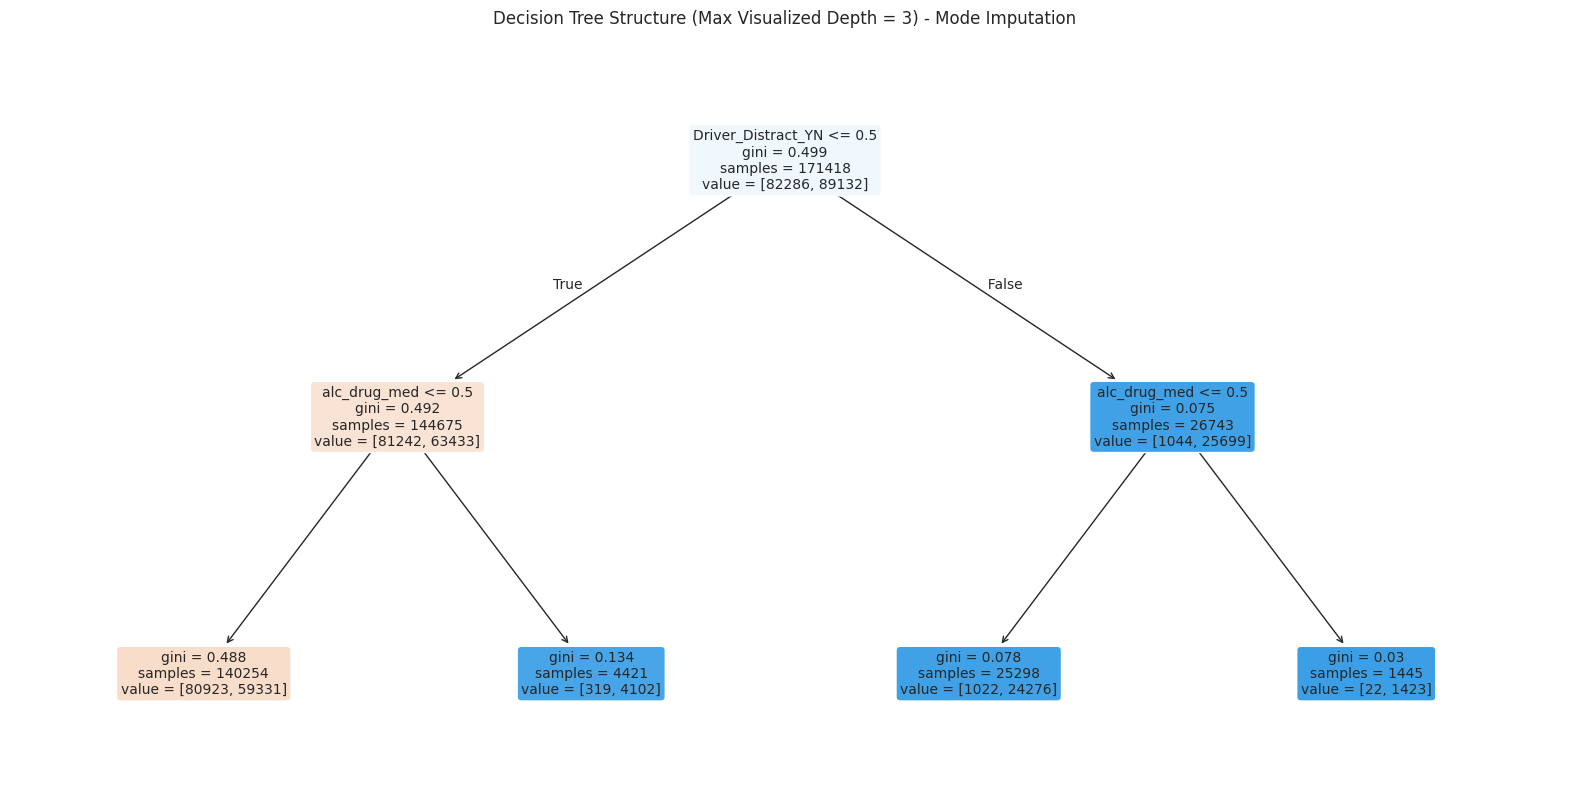

In [26]:
print("--- Decision Tree Structure Visualization (Mode Imputation) ---")

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model_mode,
    max_depth=3,  # Limit depth for a clearer image
    feature_names=X_train_mode.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Decision Tree Structure (Max Visualized Depth = 3) - Mode Imputation")
plt.show()

Comparing Evaluations of both models:  

| Model                  | MSE   | R^2    | Accuracy Score |
|:-----------------------|:------|:-------|:---------------|
| NaN rows dropped       | 0.220 | 0.040  | 0.780          |
| NaN replaced with mode | 0.355 | -0.421 | 0.645          |

For NaN rows dropped, R^2 is almost 0, so the model's predictions do not approximate the true values.

For NaN replaced with mode, a negative R² means the model performs worse than no model at all.  




Ignore
####AI use tracker:  
 - Explain: DtypeWarning: Columns (35) have mixed types.  
 Specify dtype option on import or set low_memory=False.  
 Suggest fix.

 - Explain: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method. The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.  
 Suggest fix.

 *Lesson learned:  it's best to avoid using `inplace=True`.  
 inplace=False (default): The method returns a new DataFrame/Series with the changes, and the original DataFrame/Series remains unchanged. You would typically assign this new object to a variable (e.g., df = df.fillna(value)).*

- (Re LabelEncoder):  
How do I know what integer representation was assigned to which string value?  

  What happens to the NaN values?  

  Do not fill in with mode. If any of the three variables in question from the row are NaN,  
  do not use data from that row in the analysis.